In [1]:
!pip install -r ../requirements.txt

import sys
sys.path.append('../src')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import math

import pandas as pd
import numpy as np


In [100]:
from mcTOTHelper import MCTOTHelper

#Get an instance of the helper class, using this particular calibration file
TOThelper = MCTOTHelper("../calibrations/mc_v5_tot_calibration.csv")

mcdata = pd.read_csv('../analysis_files/run_0_fpga_0.csv')

TOT saturation rate: 0.0
1651.5151515151515


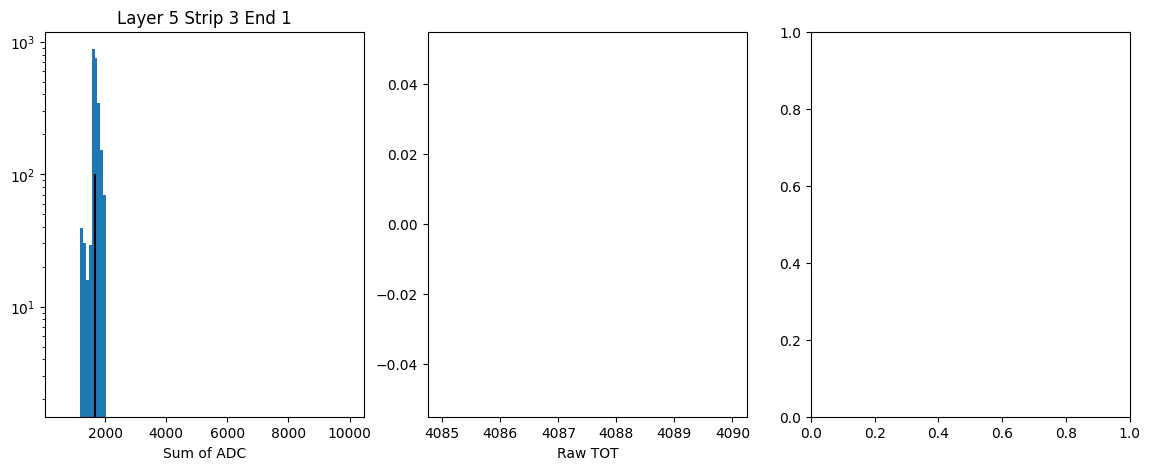

In [104]:
layer = 5
strip = 3
end = 1

events = mcdata.loc[mcdata['layer'] == layer].loc[mcdata['strip'] == strip]

sum_adc = []
tot = []
tot_corrected = []

saturated = 0

#Go through each pulse
for index, row in events.iterrows():
    #Check if this pulse is in TOT mode (returns -1 otherwise)
    if TOThelper.get_Tc_index(row,end) != -1:
        #If so, get the TOT value out of the pulse
        rawtot = TOThelper.get_TOT(row,end)
        if rawtot == 4088:
            saturated += 1
        tot.append(rawtot)
        #And correct it to sum of ADC
        tot_corrected.append(TOThelper.correct_TOT(layer,strip,end,rawtot))
    else:
        sum_adc.append(row["adc_sum_end"+str(end)])

sum_adc = [x for x in sum_adc if x > 1200 and x < 2000]

print("TOT saturation rate: " + str(saturated/len(tot)))

fig, axs = plt.subplots(1,3, figsize=(14,5))
adcbins = np.linspace(500,10000,100)
n, bins, _ = axs[0].hist(sum_adc, bins=adcbins)
axs[0].set_yscale("log")
axs[0].set_xlabel("Sum of ADC")
#totbins = np.linspace(500,4096, 50)
totbins = np.linspace(4085,4090, 6)
axs[1].hist(tot, bins=totbins)
axs[1].set_xlabel("Raw TOT")

mpv = 0
maxi = 0
for i in range(0,len(bins)-1):
    if n[i] > mpv:
        mpv = n[i]
        maxi = i+1

print(bins[maxi])        

axs[0].vlines(bins[maxi], 0, 100, color="black")

#combinedhistbins = np.linspace(500,,100)
#axs[2].hist(sum_adc, bins=combinedhistbins, histtype="step", label="ADC")
#axs[2].hist(tot_corrected,bins=combinedhistbins, label="Corrected TOT")
#axs[2].set_yscale("log")
#axs[2].set_xlabel("Sum of ADC")
#axs[2].legend()

axs[0].set_title("Layer " + str(layer) + " Strip " + str(strip) + " End " + str(end))
plt.show()

In [47]:


data = pd.read_csv('../analysis_files/run_300_aligned.csv')



Saturated fraction: 0.010146779752914295


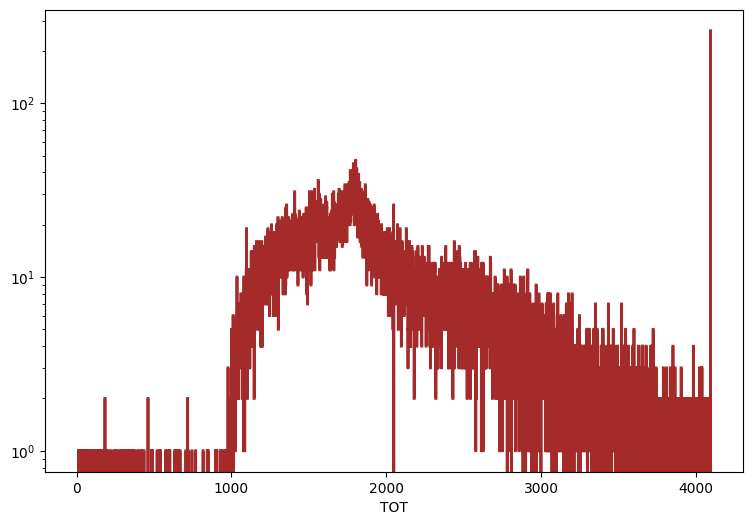

In [99]:
layer = 5
strip = 4
end = 1



#for strip in range(0,8):

events = data.loc[data['layer'] == layer].loc[data['strip'] == strip]

bins = np.linspace(0,4097,4098)
#bins = np.linspace(4090,4097,8)
totraw = []
saturated = 0
for index, row in events.iterrows():
    #If TOT is below the TOT threshold, use only ADC data
    if end == 0:
        if row['tot_end0'] > 0:
            totraw.append(row['tot_end0'])
            if row['tot_end0'] == 4095:
                saturated += 1
    else:
        if row['tot_end1'] > 0:
            totraw.append(row['tot_end1'])
            if row['tot_end1'] == 4095:
                saturated += 1

print("Saturated fraction: " + str(saturated/len(totraw)))

fig = plt.figure(figsize=(9,6))

plt.yscale("log")
plt.xlabel("TOT")
plt.hist(totraw, bins=bins, histtype="step", color="brown", label="TOT in muon events", linewidth=2)

plt.show()